Num GPUs Available:  1
Mounted at /content/drive
Models will be saved to: /content/drive/My Drive/github_projects/pneumonia_project
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:19<00:00, 236MB/s]
100% 2.29G/2.29G [00:19<00:00, 129MB/s]
Unzipping data...
Data is ready!
Visualizing NORMAL Lungs:


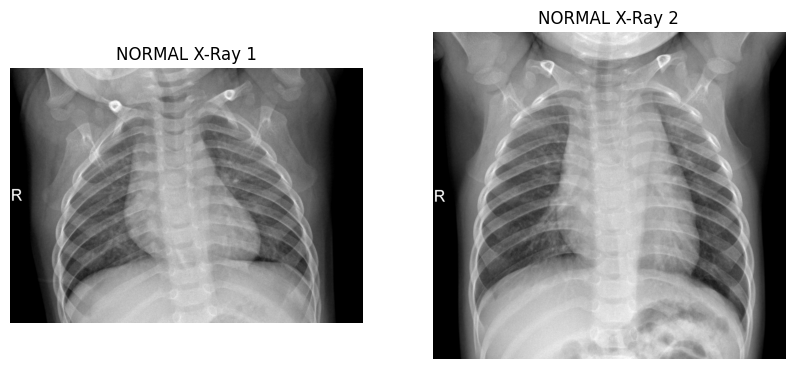


Visualizing PNEUMONIA Lungs:


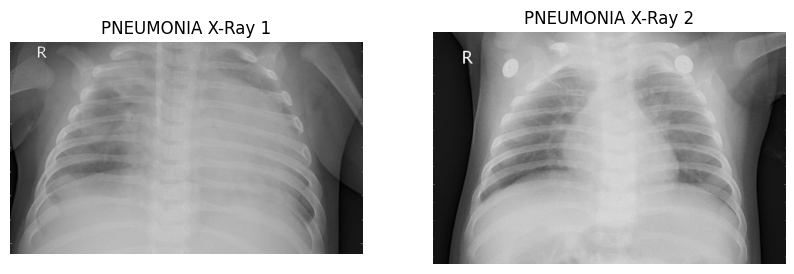

In [ ]:
### Code to create DL model for categorisation of pneumonia cases in X-ray photos ###

## Setup ##
# Import
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from google.colab import drive
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Make sure to switch CPU to GPU
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# Create a link between notebook and your Google Drive
drive.mount('/content/drive')
# Set the path to your Kaggle Key
os.environ['KAGGLE_CONFIG_DIR'] = "/content/drive/MyDrive/Kaggle"
# Create a folder in your Drive to save your trained models
model_save_path = '/content/drive/My Drive/github_projects/pneumonia_project'
os.makedirs(model_save_path, exist_ok=True)
print(f"Models will be saved to: {model_save_path}")

# Move the uploaded kaggle.json to the folder where the API expects it
!mkdir -p ~/.kaggle/
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## Data download ##

# Download the dataset directly to Collab
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
#Unzip the data
print("Unzipping data...")
!unzip -q chest-xray-pneumonia.zip
print("Data is ready!")

## Data Exploration ##
# OpenCV library for image processing

# Define the path to your training data
# Make sure unzipping did not create double folder
if os.path.exists('/content/chest_xray/train'):
    data_dir = '/content/chest_xray/train'
elif os.path.exists('/content/chest_xray/chest_xray/train'):
    data_dir = '/content/chest_xray/chest_xray/train'
else:
    print("Error: Could not find the 'train' folder. Check your files tab on the left!")
    data_dir = None

# Create function to display images of xrays
def show_lungs(condition, num_images=2):
    if data_dir is None: return
    folder_path = os.path.join(data_dir, condition)
    # Get a list of the image filenames
    image_files = os.listdir(folder_path)[:num_images]
    plt.figure(figsize=(10, 5))
    for i, image_file in enumerate(image_files):
        full_path = os.path.join(folder_path, image_file)
        img = cv2.imread(full_path)
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"{condition} X-Ray {i+1}")
        plt.axis('off')
    plt.show()

# Run the function
print("Visualizing NORMAL Lungs:")
show_lungs('NORMAL')

print("\nVisualizing PNEUMONIA Lungs:")
show_lungs('PNEUMONIA')

Visualizing NORMAL Lungs:


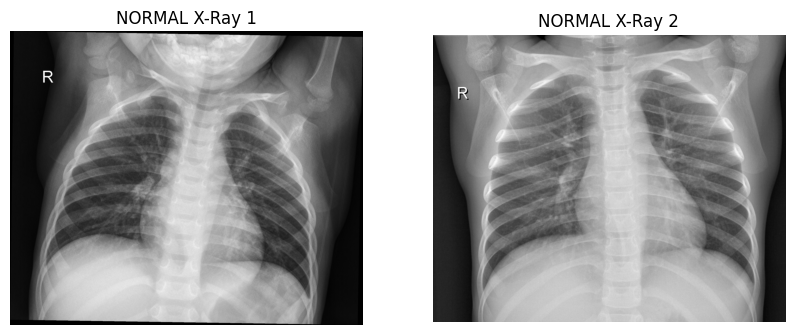


Visualizing PNEUMONIA Lungs:


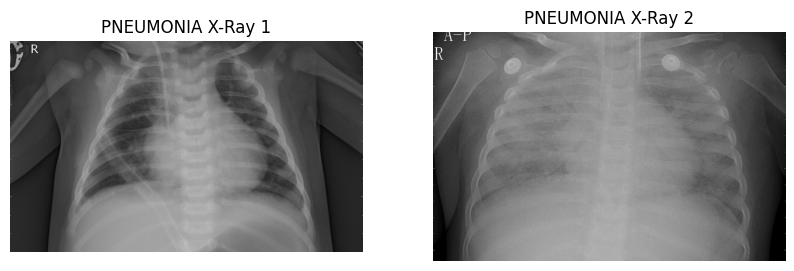

In [ ]:
import matplotlib.pyplot as plt
import os
import cv2  # OpenCV library for image processing

# Define the path to your training data
# Make sure unzip does not create doublefolder
if os.path.exists('/content/chest_xray/train'):
    data_dir = '/content/chest_xray/train'
elif os.path.exists('/content/chest_xray/chest_xray/train'):
    data_dir = '/content/chest_xray/chest_xray/train'
else:
    print("Error: Could not find the 'train' folder. Check your files tab on the left!")
    data_dir = None

# Create function to display images
def show_lungs(condition, num_images=2):
    if data_dir is None: return
    folder_path = os.path.join(data_dir, condition)
    image_files = os.listdir(folder_path)[:num_images]
    plt.figure(figsize=(10, 5))
    for i, image_file in enumerate(image_files):
        full_path = os.path.join(folder_path, image_file)
        img = cv2.imread(full_path)
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"{condition} X-Ray {i+1}")
        plt.axis('off')
    plt.show()

# Run the function
print("Visualizing NORMAL Lungs:")
show_lungs('NORMAL')

print("\nVisualizing PNEUMONIA Lungs:")
show_lungs('PNEUMONIA')

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os # Import os for path manipulation

# Define the Configuration
# We use 224x224 because that's what standard models like VGG16 expect
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32  # Process 32 images at a time

# Dynamically define the Paths
# Attempt to find the base directory of the unzipped dataset
base_data_path = None
possible_base_paths = [
    '/content/chest_xray/chest_xray', # Common path after some Kaggle unzips
    '/content/chest_xray',            # Another common path
    '/content/chest-xray-pneumonia/chest_xray', # If the zip extracts to a folder named after the zip
    '/content/chest-xray-pneumonia' # In case 'train', 'test', 'val' are directly here
]

for path in possible_base_paths:
    # Check if 'train', 'test', and 'val' subdirectories exist under this base path
    if os.path.exists(os.path.join(path, 'train')) and \
       os.path.exists(os.path.join(path, 'test')) and \
       os.path.exists(os.path.join(path, 'val')):
        base_data_path = path
        break

if base_data_path:
    train_dir = os.path.join(base_data_path, 'train')
    test_dir = os.path.join(base_data_path, 'test')
    val_dir = os.path.join(base_data_path, 'val')
    print(f"Dataset directories successfully found at: {base_data_path}")
else:
    # If no valid base path is found, this is a critical error.
    # The original error will likely persist, but we provide a diagnostic message.
    print("CRITICAL ERROR: 'train', 'test', or 'val' subdirectories not found under any expected base path.")
    print("Please inspect '/content/' to determine the correct dataset path after unzipping.")
    # Revert to original hardcoded paths to allow the FileNotFoundError to occur naturally for debugging.
    train_dir = '/content/chest_xray/chest_xray/train'
    test_dir = '/content/chest_xray/chest_xray/test'
    val_dir = '/content/chest_xray/chest_xray/val'


# Create the Generators

# Create the training Generator with data augmentation.
# This helps the model generalize better to new images.
train_datagen = ImageDataGenerator(
    rescale=1./255,        # Normalize pixel values to 0-1
    rotation_range=15,     # Rotate slightly (±15 degrees)
    zoom_range=0.2,        # Zoom in/out slightly
    horizontal_flip=True   # Flip left/right (valid for lungs)
)

# Create the test/validation generator: ONLY Rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

# Connect Generators to Folders
print("Loading Training Data:")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',   # 'binary' because we have 2 classes: Normal vs Pneumonia
    color_mode='rgb'       # Even though X-rays are B&W, VGG16 expects 3 channels (RGB)
)

print("\nLoading Test Data:")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'
)

print("\nLoading Validation Data:")
val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'
)

CRITICAL ERROR: 'train', 'test', or 'val' subdirectories not found under any expected base path.
Please inspect '/content/' to determine the correct dataset path after unzipping.
Loading Training Data:


FileNotFoundError: [Errno 2] No such file or directory: '/content/chest_xray/chest_xray/train'

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load the base model (VGG16)
# include_top=False to remove the final "classification" layers
# weights='imagenet' to use the pre-learned patterns
base_model = VGG16(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Freeze the base
for layer in base_model.layers:
    layer.trainable = False

# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

# Create the new model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the Model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Model built successfully!")
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Model built successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate Class Weights as there are more pneumonia than non-pneumonia images
train_classes = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes),
    y=train_classes
)
# Convert to a dictionary format that Keras expects
class_weights_dict = dict(enumerate(class_weights))
print(f"Class Weights: {class_weights_dict}")

# Train the Model
print("Starting Training... (This will take 15-20 minutes)")
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights_dict,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

print("Training Complete!")

Class Weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}
Starting Training... (This will take 15-20 minutes)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 134s 734ms/step - accuracy: 0.5415 - loss: 0.7361 - val_accuracy: 0.8125 - val_loss: 0.6195
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 674ms/step - accuracy: 0.7119 - loss: 0.5900 - val_accuracy: 0.7500 - val_loss: 0.5357
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 128s 784ms/step - accuracy: 0.8097 - loss: 0.4905 - val_accuracy: 0.8125 - val_loss: 0.4959
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 141s 862ms/step - accuracy: 0.8614 - loss: 0.4149 - val_accuracy: 0.8125 - val_loss: 0.4644
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 802ms/step - accuracy: 0.8708 - loss: 0.3632 - val_accuracy: 0.8125 - val_loss: 0.4371
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 139s 854ms/step - accuracy: 0.8716 - loss: 0.3355 - val_accuracy: 0.8125 - val_loss: 0.4407
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 120s 734ms/step - accuracy: 0.8779 - loss: 0.3120 - val_accuracy: 0.8125 - val_loss: 0.4071
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 701ms/step - accuracy: 0.8855 -

Found 624 images belonging to 2 classes.
Predicting on sorted data...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 327ms/step


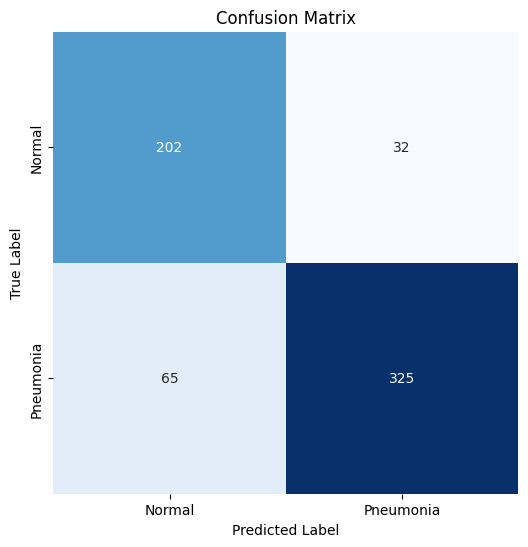

              precision    recall  f1-score   support

      Normal       0.76      0.86      0.81       234
   Pneumonia       0.91      0.83      0.87       390

    accuracy                           0.84       624
   macro avg       0.83      0.85      0.84       624
weighted avg       0.85      0.84      0.85       624



In [ ]:
## Create Confusion plot for non refined VGG16 model ##
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
# Create the test generator
test_generator_fixed = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Get predictions
print("Predicting on sorted data...")
predictions = model.predict(test_generator_fixed, steps=len(test_generator_fixed))
predicted_classes = np.where(predictions > 0.5, 1, 0)

# Get true labels
true_classes = test_generator_fixed.classes

# Generate the matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot the confusion plot
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Base VGG16 Model')
plt.show()

# Report
print(classification_report(true_classes, predicted_classes, target_names=['Normal', 'Pneumonia']))

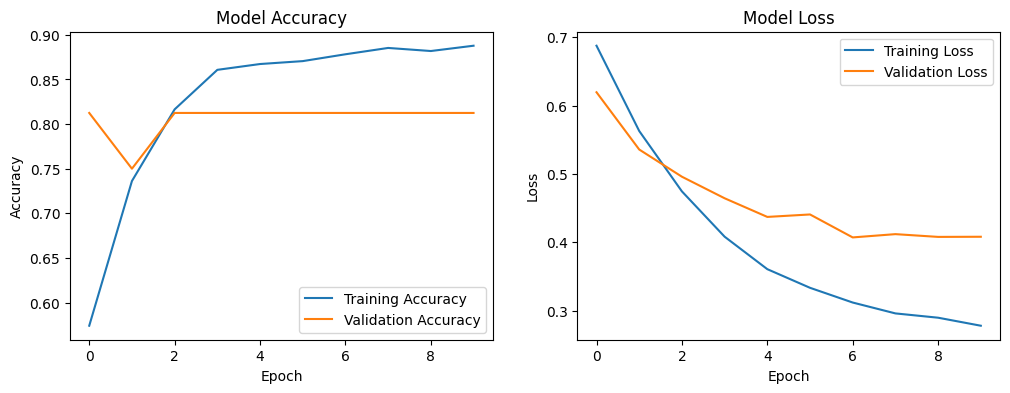

In [ ]:
## Create model accuracy and loss plot for the non-refined VGG16 model ##
import matplotlib.pyplot as plt

# Plot accuracy and loss
plt.figure(figsize=(12, 4))

# Plot subplot 1: accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot subplot 2: loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
## Save the non-refined VGG16 model to google drive
# Define the path in your Google Drive
save_path = '/content/drive/My Drive/github_projects/pneumonia_project/pneumonia_model_vgg16.keras'

# Save
model.save(save_path)
print(f"Model saved successfully at: {save_path}")

# Sanity check - verify file size
import os
size = os.path.getsize(save_path) / (1024 * 1024) # Convert to MB
print(f"File Size: {size:.2f} MB")

Model saved successfully at: /content/drive/My Drive/github_projects/pneumonia_project/pneumonia_model_vgg16.keras
File Size: 56.97 MB


In [ ]:
## Generate Grad-CAM heatmap for the non-refined VGG16 model ##
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Create function to generate heatmap
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Select an pneumonia case image from the test set
img_path = None
for i in range(len(test_generator.filenames)):
    if test_generator.classes[i] == 1: # 1 is Pneumonia
        img_path = os.path.join(test_dir, test_generator.filenames[i+5])
        break

# Preprocess the image
img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))
img_array = np.expand_dims(img, axis=0) / 255.0

# Generate the Heatmap
# 'block5_conv3' is the last convolutional layer in VGG16
heatmap = make_gradcam_heatmap(img_array, model, 'block5_conv3')

# Create the Superimposed Image
# Rescale heatmap to a range 0-255
heatmap = np.uint8(255 * heatmap)

# Use jet colormap to colorize heatmap
jet = plt.cm.get_cmap("jet")

# Use RGB values of the colormap
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap]

# Create an image with RGB colorized heatmap
jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

# Superimpose the heatmap on original image
superimposed_img = jet_heatmap * 0.4 + img # 0.4 is transparency
superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

# Visualize
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original X-Ray")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title("AI Attention (Heatmap)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img)
plt.title("Overlay")
plt.axis('off')
plt.show()

NameError: name 'test_generator' is not defined

In [ ]:
## Create more finetuned VGG16 model ##
# Unfreeze the base model
base_model.trainable = True

# Freeze all layers except the last block (Block 5)
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Re-compile with a low learning rate (1e-5)
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train for 5 more epochs
history_fine = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    class_weight=class_weights_dict
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 656ms/step - accuracy: 0.8874 - loss: 0.2810 - val_accuracy: 0.8125 - val_loss: 0.4187
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 658ms/step - accuracy: 0.8945 - loss: 0.2609 - val_accuracy: 0.8125 - val_loss: 0.4225
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 661ms/step - accuracy: 0.8908 - loss: 0.2685 - val_accuracy: 0.8125 - val_loss: 0.4214
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 662ms/step - accuracy: 0.8949 - loss: 0.2558 - val_accuracy: 0.8125 - val_loss: 0.4203
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 658ms/step - accuracy: 0.8891 - loss: 0.2704 - val_accuracy: 0.8125 - val_loss: 0.4190


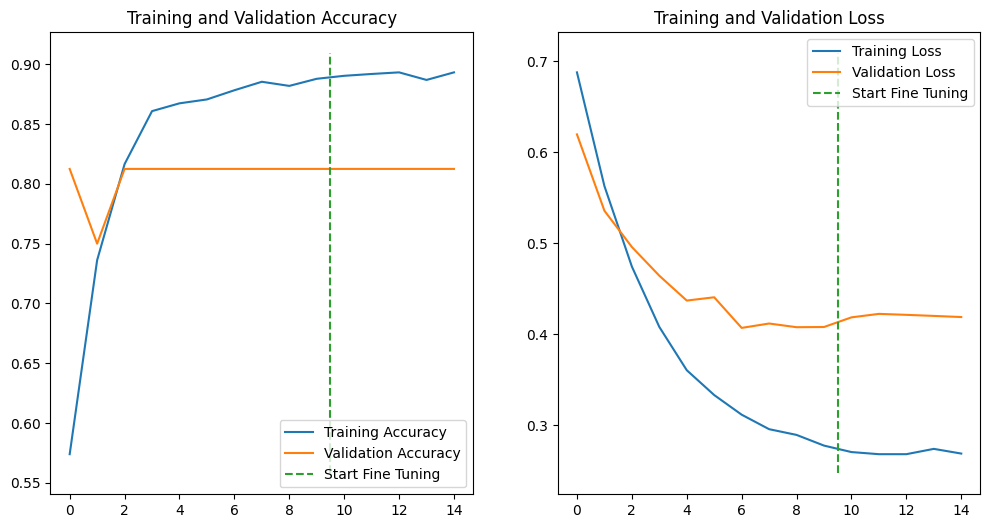

In [ ]:
## Create model accuracy and loss plot for the more finetuned VGG16 model ##
import matplotlib.pyplot as plt

# Combine the history from both training phases
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

# Set up the plot
plt.figure(figsize=(12, 6))

# Accuracy plot setup
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.plot([9.5, 9.5], plt.ylim(), label='Start Fine Tuning', linestyle='--')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Loss plot setup
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.plot([9.5, 9.5], plt.ylim(), label='Start Fine Tuning', linestyle='--')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

Predicting with Fine-Tuned Model...
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 262ms/step


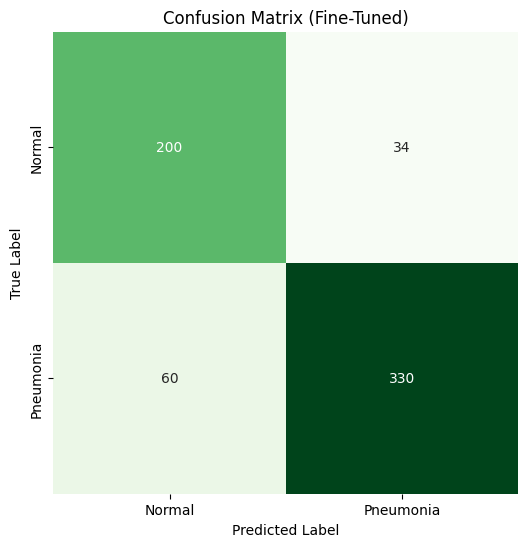

              precision    recall  f1-score   support

      Normal       0.77      0.85      0.81       234
   Pneumonia       0.91      0.85      0.88       390

    accuracy                           0.85       624
   macro avg       0.84      0.85      0.84       624
weighted avg       0.86      0.85      0.85       624



In [ ]:
## Create confusion plot for the more finetuned VGG16 model ##
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Reset the test generator
test_generator_fixed.reset()

# Get new predictions with the finetuned model
print("Predicting with Fine-Tuned Model...")
predictions = model.predict(test_generator_fixed, steps=len(test_generator_fixed))
predicted_classes = np.where(predictions > 0.5, 1, 0)
true_classes = test_generator_fixed.classes

# Create matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot confusion plot
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (More Fine-Tuned VGG16 Model)')
plt.show()

# Print Stats
print(classification_report(true_classes, predicted_classes, target_names=['Normal', 'Pneumonia']))

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/tmp/ipython-input-1901915850.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


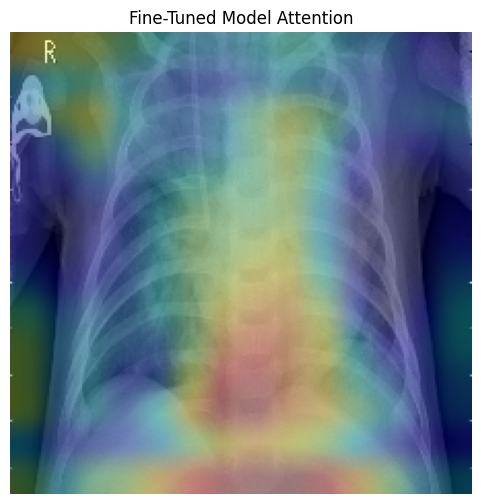

In [ ]:
## Generate Grad-CAM heatmap for the more finetuned VGG16 model ##
import cv2

# Create function to generate heatmap
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Pick the same image as before for a fair comparison
img_path = None
for i in range(len(test_generator_fixed.filenames)):
    if test_generator_fixed.classes[i] == 1:
        img_path = os.path.join(test_dir, test_generator_fixed.filenames[i+5])
        break

# Preprocess image
img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))
img_array = np.expand_dims(img, axis=0) / 255.0

# Generate heatmap (using the updated 'model')
heatmap = make_gradcam_heatmap(img_array, model, 'block5_conv3')

# Create the Superimposed Image
# Rescale heatmap to a range 0-255
heatmap = np.uint8(255 * heatmap)

# Use jet colormap to colorize heatmap
jet = plt.cm.get_cmap("jet")

# Use RGB values of the colormap
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap]

# Create an image with RGB colorized heatmap
jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

# Superimpose the heatmap on original image
superimposed_img = jet_heatmap * 0.4 + img # 0.4 is transparency
superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

# Visualize
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original X-Ray")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title("AI Attention (Heatmap)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img)
plt.title("Overlay")
plt.axis('off')
plt.show()

In [ ]:
## Create less finetuned VGG16 model ##
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

# Reload the original VG16 base model
# Ensure the path matches where you saved it earlier
load_path = '/content/drive/My Drive/github_projects/pneumonia_project/pneumonia_model_vgg16_1.keras'
print(f"Reloading model from {load_path}...")
model = tf.keras.models.load_model(load_path)

# Set trainable status for each layer
for i, layer in enumerate(model.layers):
    if i < 15: # Freeze layers from 'input_layer' up to 'block4_pool'
        layer.trainable = False
    else: # Keep 'block5_conv1' and subsequent layers (including the custom head) trainable
        layer.trainable = True


# Compile with new lower learning rate (1e-6)
model.compile(optimizer=Adam(learning_rate=1e-6),
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Model ready for gentle fine-tuning.")

# Train new model for 5 Epochs
history_fine_v2 = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    class_weight=class_weights_dict
)

Reloading model from /content/drive/My Drive/github_projects/pneumonia_project/pneumonia_model_vgg16_1.keras...
Model ready for gentle fine-tuning.
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 119s 694ms/step - accuracy: 0.8977 - loss: 0.2590 - val_accuracy: 0.8125 - val_loss: 0.4007
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 683ms/step - accuracy: 0.9022 - loss: 0.2345 - val_accuracy: 0.7500 - val_loss: 0.3782
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 683ms/step - accuracy: 0.9196 - loss: 0.2042 - val_accuracy: 0.8125 - val_loss: 0.4162
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 682ms/step - accuracy: 0.9271 - loss: 0.1848 - val_accuracy: 0.8125 - val_loss: 0.3939
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 685ms/step - accuracy: 0.9244 - loss: 0.1821 - val_accuracy: 0.8125 - val_loss: 0.3541


Predicting with V2 Fine-Tuned Model...
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 616ms/step


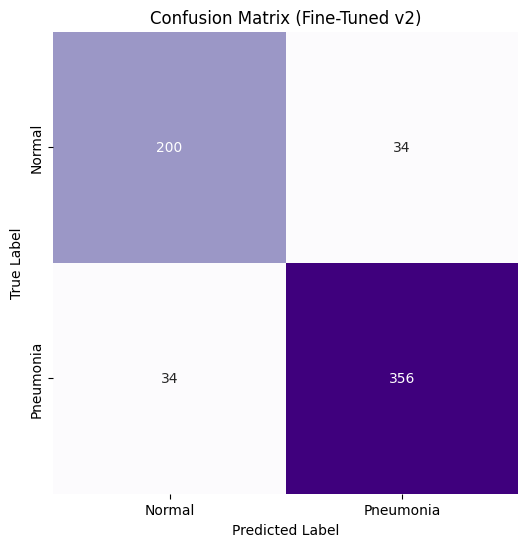

              precision    recall  f1-score   support

      Normal       0.85      0.85      0.85       234
   Pneumonia       0.91      0.91      0.91       390

    accuracy                           0.89       624
   macro avg       0.88      0.88      0.88       624
weighted avg       0.89      0.89      0.89       624



In [ ]:
## Create Confusion plot for less finetuned VGG16 model ##
# Reset Generator
test_generator_fixed.reset()

# Predict
print("Predicting with V2 Fine-Tuned Model...")
predictions = model.predict(test_generator_fixed, steps=len(test_generator_fixed))
predicted_classes = np.where(predictions > 0.5, 1, 0)
true_classes = test_generator_fixed.classes

# Create confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (More Fine-Tuned VGG16 Model)')
plt.show()

# Print model statistics
print(classification_report(true_classes, predicted_classes, target_names=['Normal', 'Pneumonia']))

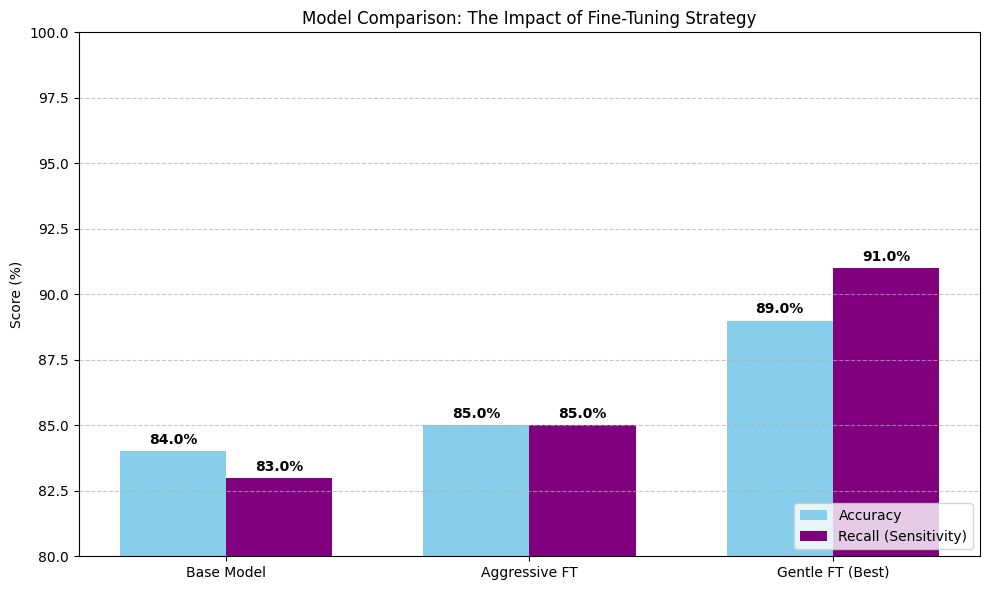

In [ ]:
## Create comparison barchart for the three VGG16 models ##
import matplotlib.pyplot as plt
import numpy as np

# Input data from the three models
models = ['Base Model', 'Aggressive FT', 'Gentle FT (Best)']
accuracies = [84, 85, 89]
recalls = [83, 85, 91]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Create bars for the barchart
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x + width/2, recalls, width, label='Recall (Sensitivity)', color='purple')

# Create labels and styling settings
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison: The Impact of Fine-Tuning Strategy')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim([80, 100])
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Create helper function to put numbers on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

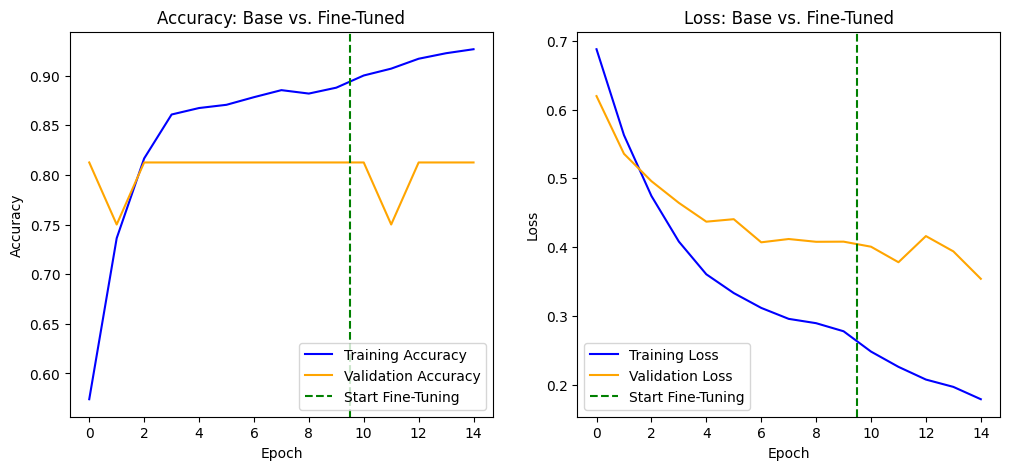

In [ ]:
## Create model accuracy and loss plot for the less finetuned VGG16 model ##
acc = history.history['accuracy'] + history_fine_v2.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine_v2.history['val_accuracy']
loss = history.history['loss'] + history_fine_v2.history['loss']
val_loss = history.history['val_loss'] + history_fine_v2.history['val_loss']

plt.figure(figsize=(12, 5))

# Create accuracy plot
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy', color='blue')
plt.plot(val_acc, label='Validation Accuracy', color='orange')
plt.axvline(x=9.5, color='green', linestyle='--', label='Start Fine-Tuning')
plt.title('Accuracy: Base vs. Fine-Tuned')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Create loss plot
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.axvline(x=9.5, color='green', linestyle='--', label='Start Fine-Tuning')
plt.title('Loss: Base vs. Fine-Tuned')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/tmp/ipython-input-2012130357.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


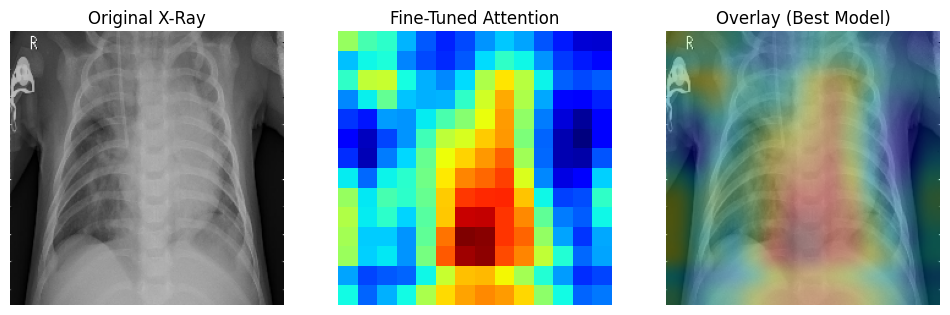

In [ ]:
## Generate Grad-CAM heatmap for the more finetuned VGG16 model ##
import cv2

# Select the same Pneumonia image for consistency
img_path = None
# Ensure generator is reset to find the same index
test_generator_fixed.reset()
for i in range(len(test_generator_fixed.filenames)):
    if test_generator_fixed.classes[i] == 1: # 1 is Pneumonia
        img_path = os.path.join(test_dir, test_generator_fixed.filenames[i+5])
        break

# Create function to generate heatmap
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Preprocess image
img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))
img_array = np.expand_dims(img, axis=0) / 255.0

# Generate Heatmap
heatmap = make_gradcam_heatmap(img_array, model, 'block5_conv3')

heatmap = np.uint8(255 * heatmap)
jet = plt.cm.get_cmap("jet")
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap]

jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

superimposed_img = jet_heatmap * 0.4 + img # 0.4 is transparency
superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

# Plot heatmap
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original X-Ray")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title("Fine-Tuned Attention")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img)
plt.title("Overlay (Best Model)")
plt.axis('off')
plt.show()

In [ ]:
## Create base DenseNet121 model ##
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load DenseNet121 Base
densenet_base = DenseNet121(input_shape=(224, 224, 3),
                            include_top=False,
                            weights='imagenet')

# Freeze the pre-trained base layers
for layer in densenet_base.layers:
    layer.trainable = False

# Add custom head layers
x = densenet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

# Compile model
densenet_model = Model(inputs=densenet_base.input, outputs=predictions)
densenet_model.compile(optimizer=Adam(learning_rate=0.0001),
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

print("DenseNet121 Model Built!")

# Train model
print("Starting DenseNet Training...")
history_dense = densenet_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights_dict,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
DenseNet121 Model Built!
Starting DenseNet Training...
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 150s 741ms/step - accuracy: 0.6302 - loss: 0.6629 - val_accuracy: 0.7500 - val_loss: 0.4228
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 643ms/step - accuracy: 0.8562 - loss: 0.3297 - val_accuracy: 0.7500 - val_loss: 0.4435
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 647ms/step - accuracy: 0.8923 - loss: 0.2716 - val_accuracy: 0.7500 - val_loss: 0.3592
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 640ms/step - accuracy: 0.9119 - loss: 0.2270 - val_accuracy: 0.7500 - val_loss: 0.3440
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 645ms/step - accuracy: 0.9079 - loss: 0.2285 - val_accuracy: 0.7500 - val_loss: 0.3399
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 643ms/step - accuracy: 0.9102 - loss: 0.2021 - val_accuracy: 0.7500 - val_loss: 0.3280
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 641ms/step - accuracy: 0.9266 - loss: 0.1830 - val_accura

In [ ]:
## Create Confusion plot for base DenseNet121 model ##
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Reset test generator
test_generator_fixed.reset()

# Get Predictions from DenseNet
print("Generating DenseNet Predictions...")
pred_dense = densenet_model.predict(test_generator_fixed, steps=len(test_generator_fixed))
pred_dense_classes = np.where(pred_dense > 0.5, 1, 0) # Threshold 0.5
true_classes = test_generator_fixed.classes

# Generate confusion matrix
cm_dense = confusion_matrix(true_classes, pred_dense_classes)

# Plot matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm_dense, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (DenseNet121)')
plt.show()

# Print report statistics
print(classification_report(true_classes, pred_dense_classes, target_names=['Normal', 'Pneumonia']))

NameError: name 'test_generator_fixed' is not defined

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_67']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Generating Grad-CAM using layer: relu


/tmp/ipython-input-1326090823.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


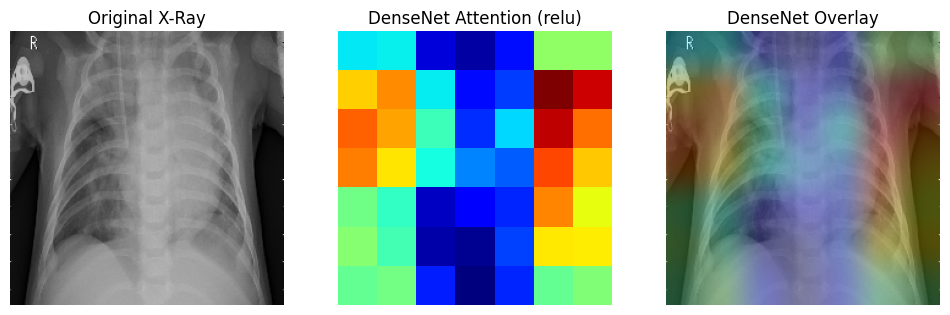

In [ ]:
## Generate Grad-CAM heatmap for the more finetuned VGG16 model ##
import cv2

# Create function to generate heatmap
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Select the same pneumonia image for fair comparison
img_path = None
for i in range(len(test_generator_fixed.filenames)):
    if test_generator_fixed.classes[i] == 1:
        img_path = os.path.join(test_dir, test_generator_fixed.filenames[i+5])
        break

# Preprocess image
img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))
img_array = np.expand_dims(img, axis=0) / 255.0

# Generate Heatmap
try:
    target_layer = 'relu'
    heatmap = make_gradcam_heatmap(img_array, densenet_model, target_layer)
except ValueError:
    target_layer = 'conv5_block16_2_conv'
    heatmap = make_gradcam_heatmap(img_array, densenet_model, target_layer)

print(f"Generating Grad-CAM using layer: {target_layer}")

# Colorize and overlay heatmap
heatmap = np.uint8(255 * heatmap)
jet = plt.cm.get_cmap("jet")
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap]
jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)
superimposed_img = jet_heatmap * 0.4 + img
superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

# Visualize heatmap
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original X-Ray")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title(f"DenseNet Attention ({target_layer})")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img)
plt.title("DenseNet Overlay")
plt.axis('off')
plt.show()

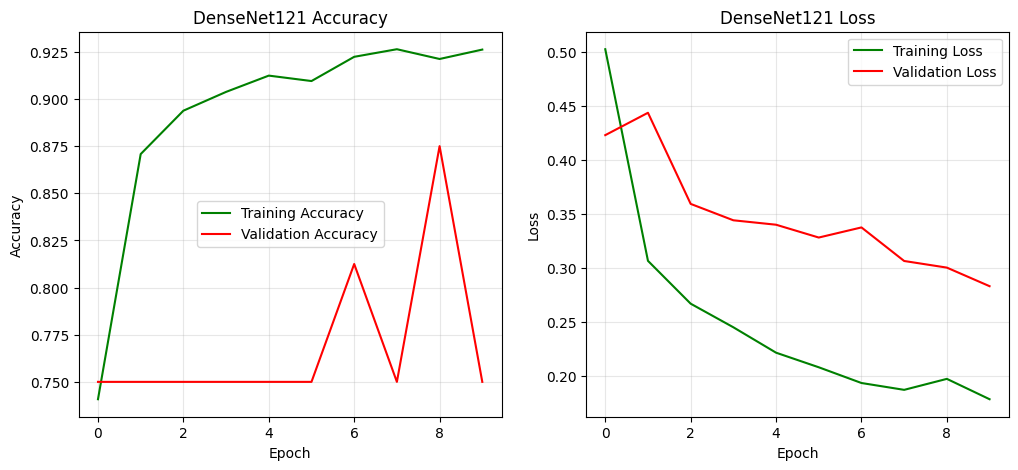

In [ ]:
## Create model accuracy and loss plot for the base DenseNet121 model ##
import matplotlib.pyplot as plt

# Plot accuracy and loss for DenseNet121
plt.figure(figsize=(12, 5))

# Subplot 1: accuracy
plt.subplot(1, 2, 1)
plt.plot(history_dense.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history_dense.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.title('Base DenseNet121 Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: loss
plt.subplot(1, 2, 2)
plt.plot(history_dense.history['loss'], label='Training Loss', color='green')
plt.plot(history_dense.history['val_loss'], label='Validation Loss', color='red')
plt.title(' Base DenseNet121 Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Generating DenseNet Predictions...
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 293ms/step


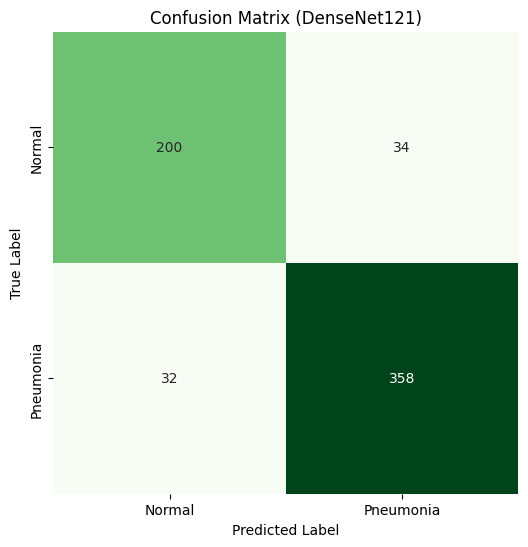

              precision    recall  f1-score   support

      Normal       0.86      0.85      0.86       234
   Pneumonia       0.91      0.92      0.92       390

    accuracy                           0.89       624
   macro avg       0.89      0.89      0.89       624
weighted avg       0.89      0.89      0.89       624



In [ ]:
## Create confusion matrix plot for the base DenseNet121 model ##
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Reset Test Generator
test_generator_fixed.reset()

# Get Predictions from DenseNet
print("Generating DenseNet Predictions...")
pred_dense = densenet_model.predict(test_generator_fixed, steps=len(test_generator_fixed))
pred_dense_classes = np.where(pred_dense > 0.5, 1, 0) # Threshold 0.5
true_classes = test_generator_fixed.classes

# Generate Matrix
cm_dense = confusion_matrix(true_classes, pred_dense_classes)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm_dense, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (base DenseNet121 model)')
plt.show()

# Print Report
print(classification_report(true_classes, pred_dense_classes, target_names=['Normal', 'Pneumonia']))

In [ ]:
## Save Base DenseNet121 and less finetuned VGG16 models ##
import os
from google.colab import drive
import tensorflow as tf

drive.mount('/content/drive')

# Define the Save Location
save_dir = '/content/drive/My Drive/github_projects/pneumonia_project/'

# Create the folder if it doesn't exist yet
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Created directory: {save_dir}")

# Save less finetuned VGG16 model
vgg_save_path = os.path.join(save_dir, 'pneumonia_vgg16_finetuned_best.keras')
model.save(vgg_save_path)
print(f"✅ VGG16 (Fine-Tuned) saved to: {vgg_save_path}")

# Save base DenseNet121 model
try:
    densenet_save_path = os.path.join(save_dir, 'pneumonia_densenet.keras')
    densenet_model.save(densenet_save_path)
    print(f"✅ DenseNet saved to: {densenet_save_path}")
except NameError:
    print("⚠️ Could not find a variable named 'defnet_model'. Check your variable name!")

# 3. Verify File Sizes (Sanity Check)
# A good VGG16 model should be around ~60MB - 100MB depending on the optimizer state
print("\n--- File Verification ---")
if os.path.exists(vgg_save_path):
    size_mb = os.path.getsize(vgg_save_path) / (1024 * 1024)
    print(f"VGG16 File Size: {size_mb:.2f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ VGG16 (Fine-Tuned) saved to: /content/drive/My Drive/github_projects/pneumonia_project/pneumonia_vgg16_finetuned_best.keras
✅ DenseNet saved to: /content/drive/My Drive/github_projects/pneumonia_project/pneumonia_defnet.keras

--- File Verification ---
VGG16 File Size: 110.99 MB


In [ ]:
## Create finetuned DenseNet121 model ##
import tensorflow as tf
from tensorflow.keras.optimizers import Adam


# Unfreeze the base model
densenet_base.trainable = True

# Freeze early layers, unfreeze Last 50 Layers
total_layers = len(densenet_base.layers)
fine_tune_at = total_layers - 50

print(f"Total Layers: {total_layers}")
print(f"Freezing layers 0 to {fine_tune_at}. Unfreezing the rest.")

for layer in densenet_base.layers[:fine_tune_at]:
    layer.trainable = False

# Compile model with small learning Rate (1e-6) - same as in less finetuned VGG16 model
densenet_model.compile(optimizer=Adam(learning_rate=1e-6),
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

print("DenseNet ready for gentle fine-tuning.")

# Train model
history_fine_dense = densenet_model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    class_weight=class_weights_dict
)

Total Layers: 427
Freezing layers 0 to 377. Unfreezing the rest.
DenseNet ready for gentle fine-tuning.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 143s 722ms/step - accuracy: 0.9292 - loss: 0.1855 - val_accuracy: 0.7500 - val_loss: 0.2820
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 644ms/step - accuracy: 0.9328 - loss: 0.1829 - val_accuracy: 0.8125 - val_loss: 0.2813
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 647ms/step - accuracy: 0.9362 - loss: 0.1745 - val_accuracy: 0.8125 - val_loss: 0.2808
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 646ms/step - accuracy: 0.9344 - loss: 0.1739 - val_accuracy: 0.8125 - val_loss: 0.2802
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 640ms/step - accuracy: 0.9312 - loss: 0.1643 - val_accuracy: 0.8125 - val_loss: 0.2800


In [ ]:
## Save finetuned DenseNet121 model ##
import os

# Define path
save_path_dense = '/content/drive/My Drive/github_projects/pneumonia_project/pneumonia_densenet_finetuned.keras'

# Save model
densenet_model.save(save_path_dense)
print(f"✅ DenseNet saved successfully at: {save_path_dense}")

# Verify size
size = os.path.getsize(save_path_dense) / (1024 * 1024)
print(f"File Size: {size:.2f} MB")

✅ DenseNet saved successfully at: /content/drive/My Drive/github_projects/pneumonia_project/pneumonia_densenet_finetuned.keras
File Size: 29.80 MB


Generating predictions with Fine-Tuned DenseNet...
20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 946ms/step


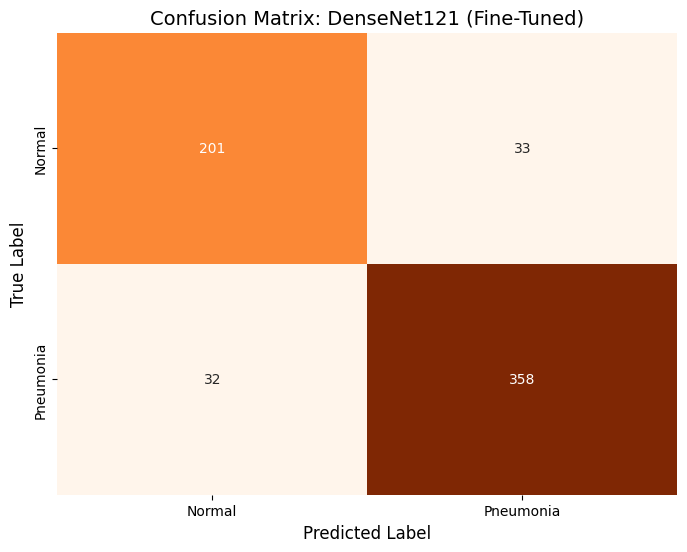


--- DenseNet Fine-Tuned Classification Report ---
              precision    recall  f1-score   support

      Normal       0.86      0.86      0.86       234
   Pneumonia       0.92      0.92      0.92       390

    accuracy                           0.90       624
   macro avg       0.89      0.89      0.89       624
weighted avg       0.90      0.90      0.90       624



In [ ]:
## Create confusion matrix for finetuned DenseNet121 model ##
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Reset the test generator
test_generator_fixed.reset()

# Generate predictions
print("Generating predictions with Fine-Tuned DenseNet...")
predictions = densenet_model.predict(test_generator_fixed, steps=len(test_generator_fixed))

# Apply threshold
predicted_classes = np.where(predictions > 0.5, 1, 0)
true_classes = test_generator_fixed.classes

# Compute confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix: DenseNet121 (Fine-Tuned)', fontsize=14)
plt.show()

# Print detailed metrics
print("\n--- DenseNet Fine-Tuned Classification Report ---")
print(classification_report(true_classes, predicted_classes, target_names=['Normal', 'Pneumonia']))

In [ ]:
# Print the names of the last 10 layers of your DenseNet model
# We are looking for something like 'conv5_block16_concat' or 'bn'
for i, layer in enumerate(densenet_model.layers[-10:]):
    print(f"Index: {-10+i} | Name: {layer.name}")

Index: -10 | Name: conv5_block16_1_bn
Index: -9 | Name: conv5_block16_1_relu
Index: -8 | Name: conv5_block16_2_conv
Index: -7 | Name: conv5_block16_concat
Index: -6 | Name: bn
Index: -5 | Name: relu
Index: -4 | Name: global_average_pooling2d_1
Index: -3 | Name: dense_2
Index: -2 | Name: dropout_1
Index: -1 | Name: dense_3


/tmp/ipython-input-4109813950.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


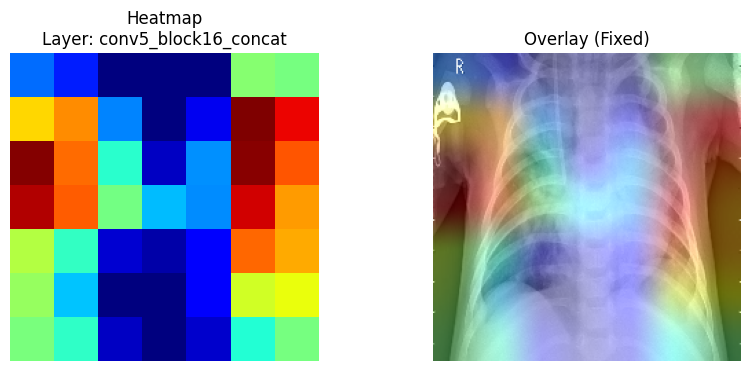

In [ ]:
##Create Grad-CAM heatmap for finetuned DenseNet121 model
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf

target_layer_name = 'conv5_block16_concat'

# Select the Same pneumonia image to use
test_generator_fixed.reset()
img_path = None
for i in range(len(test_generator_fixed.filenames)):
    if test_generator_fixed.classes[i] == 1:
        img_path = os.path.join(test_dir, test_generator_fixed.filenames[i+5])
        break

#Load Image
img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))

# Prepare for Model
img_array = np.expand_dims(img, axis=0) / 255.0

#Create heatmap
try:
    heatmap = make_gradcam_heatmap(img_array, densenet_model, target_layer_name)
except ValueError:
    print(f"⚠️ Error: Could not find layer '{target_layer_name}'. Please run Step 1 to check layer names.")
    heatmap = np.zeros((224,224))

# Make visualisation fixes to heatmap
heatmap = np.uint8(255 * heatmap)

# Use new Matplotlib API for colormap
jet = cm.get_cmap("jet")
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap]

# Resize heatmap to match original image
jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

# Create Overlay
superimposed_img = (jet_heatmap/255.0) * 0.4 + (img/255.0)

# Clip values to ensure they stay between 0 and 1
superimposed_img = np.clip(superimposed_img, 0.0, 1.0)

# --- PLOT ---
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(heatmap, cmap='jet')
plt.title(f"Heatmap\nLayer: {target_layer_name}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(superimposed_img)
plt.title("Overlay (Fixed)")
plt.axis('off')

plt.show()

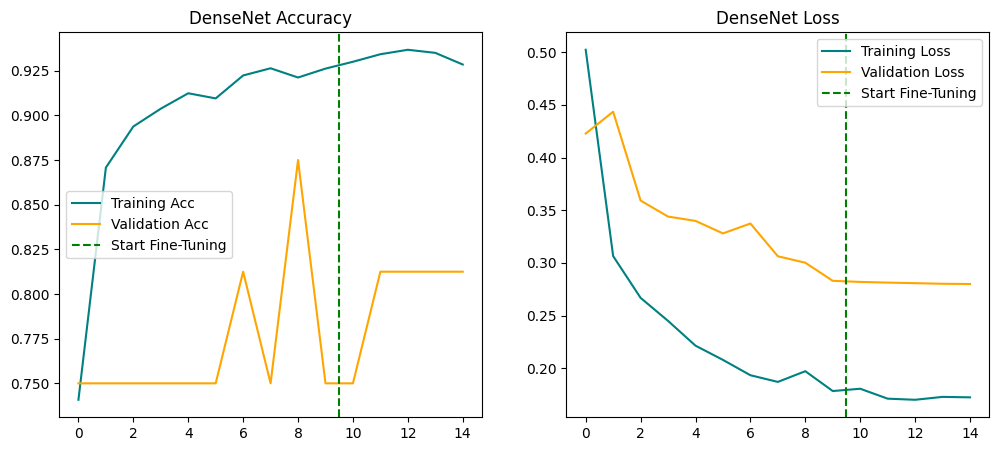

In [ ]:
## Create accuracy and loss plot for finetuned DenseNet121 model ##
import matplotlib.pyplot as plt

try:
    acc = history_dense.history['accuracy'] + history_fine_dense.history['accuracy']
    val_acc = history_dense.history['val_accuracy'] + history_fine_dense.history['val_accuracy']
    loss = history_dense.history['loss'] + history_fine_dense.history['loss']
    val_loss = history_dense.history['val_loss'] + history_fine_dense.history['val_loss']
    start_epoch = len(history_dense.history['accuracy']) - 0.5
except NameError:
    acc = history_fine_dense.history['accuracy']
    val_acc = history_fine_dense.history['val_accuracy']
    loss = history_fine_dense.history['loss']
    val_loss = history_fine_dense.history['val_loss']
    start_epoch = 0

# Plot figure
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Acc', color='teal')
plt.plot(val_acc, label='Validation Acc', color='orange')
if start_epoch > 0:
    plt.axvline(x=start_epoch, color='green', linestyle='--', label='Start Fine-Tuning')
plt.title('DenseNet Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss', color='teal')
plt.plot(val_loss, label='Validation Loss', color='orange')
if start_epoch > 0:
    plt.axvline(x=start_epoch, color='green', linestyle='--', label='Start Fine-Tuning')
plt.title('DenseNet Loss')
plt.legend()

#Show plot
plt.show()

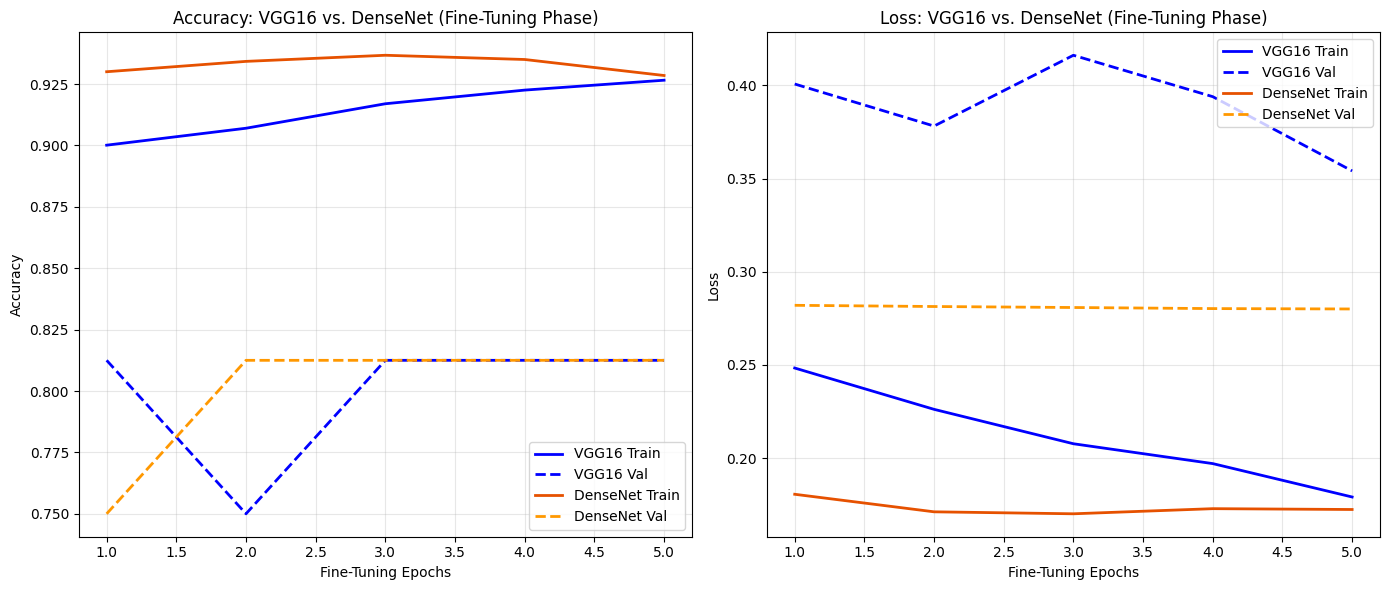

In [ ]:
##Compare accuracy and loss for the finetuning phase in the finetuned DenseNet121 model and less finetuned VGG16 model
import matplotlib.pyplot as plt

# Access the history from your two fine-tuning runs
# VGG16 (Blue Theme)
vgg_acc = history_fine_v2.history['accuracy']
vgg_val_acc = history_fine_v2.history['val_accuracy']
vgg_loss = history_fine_v2.history['loss']
vgg_val_loss = history_fine_v2.history['val_loss']

# DenseNet (Orange Theme)
dense_acc = history_fine_dense.history['accuracy']
dense_val_acc = history_fine_dense.history['val_accuracy']
dense_loss = history_fine_dense.history['loss']
dense_val_loss = history_fine_dense.history['val_loss']

epochs = range(1, len(vgg_acc) + 1)

# Create the plot
plt.figure(figsize=(14, 6))

# Plot accuracy comparison
plt.subplot(1, 2, 1)
# VGG16 lines
plt.plot(epochs, vgg_acc, 'b-', label='VGG16 Train', linewidth=2)
plt.plot(epochs, vgg_val_acc, 'b--', label='VGG16 Val', linewidth=2)
# DenseNet lines
plt.plot(epochs, dense_acc, color='#e65100', linestyle='-', label='DenseNet Train', linewidth=2)
plt.plot(epochs, dense_val_acc, color='#ff9800', linestyle='--', label='DenseNet Val', linewidth=2)

plt.title('Accuracy: VGG16 vs. DenseNet (Fine-Tuning Phase)')
plt.xlabel('Fine-Tuning Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot loss comparison
plt.subplot(1, 2, 2)
# VGG16 lines
plt.plot(epochs, vgg_loss, 'b-', label='VGG16 Train', linewidth=2)
plt.plot(epochs, vgg_val_loss, 'b--', label='VGG16 Val', linewidth=2)
# DenseNet lines
plt.plot(epochs, dense_loss, color='#e65100', linestyle='-', label='DenseNet Train', linewidth=2)
plt.plot(epochs, dense_val_loss, color='#ff9800', linestyle='--', label='DenseNet Val', linewidth=2)

plt.title('Loss: VGG16 vs. DenseNet (Fine-Tuning Phase)')
plt.xlabel('Fine-Tuning Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

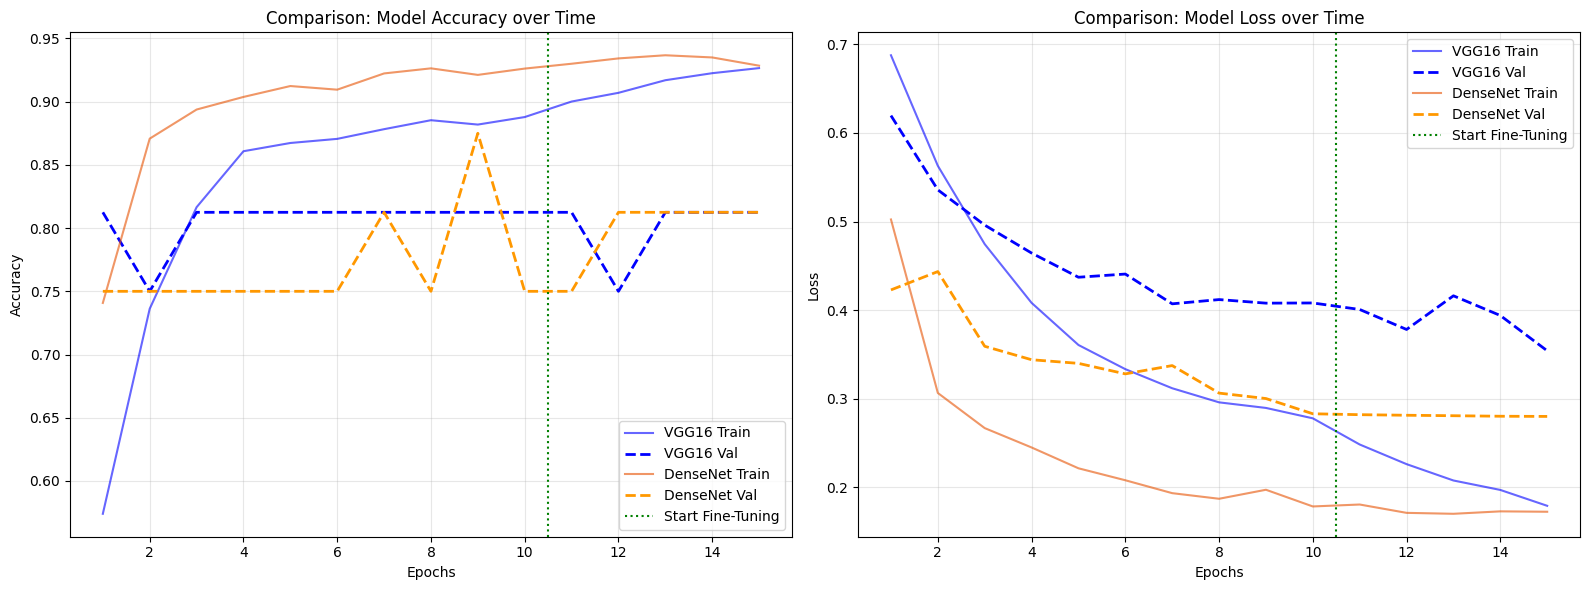

In [ ]:
## comapre accuracy and loss values for refined DenseNet121 and less refined VGG16 models
import matplotlib.pyplot as plt

# VGG16 Data (Blue Theme)
vgg_acc = history.history['accuracy'] + history_fine_v2.history['accuracy']
vgg_val_acc = history.history['val_accuracy'] + history_fine_v2.history['val_accuracy']
vgg_loss = history.history['loss'] + history_fine_v2.history['loss']
vgg_val_loss = history.history['val_loss'] + history_fine_v2.history['val_loss']

# DenseNet Data (Orange Theme)
dense_acc = history_dense.history['accuracy'] + history_fine_dense.history['accuracy']
dense_val_acc = history_dense.history['val_accuracy'] + history_fine_dense.history['val_accuracy']
dense_loss = history_dense.history['loss'] + history_fine_dense.history['loss']
dense_val_loss = history_dense.history['val_loss'] + history_fine_dense.history['val_loss']

# Define the timeline
epochs_range = range(1, len(vgg_acc) + 1)
# Find where fine-tuning started (length of the first phase)
ft_start = len(history.history['accuracy']) + 0.5

#Plot figure
plt.figure(figsize=(16, 6))

# Plot accuracy
plt.subplot(1, 2, 1)
# VGG16
plt.plot(epochs_range, vgg_acc, label='VGG16 Train', color='blue', alpha=0.6)
plt.plot(epochs_range, vgg_val_acc, label='VGG16 Val', color='blue', linestyle='--', linewidth=2)
# DenseNet
plt.plot(epochs_range, dense_acc, label='DenseNet Train', color='#e65100', alpha=0.6)
plt.plot(epochs_range, dense_val_acc, label='DenseNet Val', color='#ff9800', linestyle='--', linewidth=2)

# Mark the transition
plt.axvline(x=ft_start, color='green', linestyle=':', label='Start Fine-Tuning')

plt.title('Comparison: Model Accuracy over Time')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)


# Plot loss
plt.subplot(1, 2, 2)
# VGG16
plt.plot(epochs_range, vgg_loss, label='VGG16 Train', color='blue', alpha=0.6)
plt.plot(epochs_range, vgg_val_loss, label='VGG16 Val', color='blue', linestyle='--', linewidth=2)
# DenseNet
plt.plot(epochs_range, dense_loss, label='DenseNet Train', color='#e65100', alpha=0.6)
plt.plot(epochs_range, dense_val_loss, label='DenseNet Val', color='#ff9800', linestyle='--', linewidth=2)

# Mark the transition
plt.axvline(x=ft_start, color='green', linestyle=':', label='Start Fine-Tuning')

plt.title('Comparison: Model Loss over Time')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()

#Show plot
plt.show()